## 25.11.09: Full Pipeline

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise
from copy import deepcopy

import numpy as np
import scipy
from scipy.spatial import Delaunay

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from sklearn.cluster import AffinityPropagation, DBSCAN
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import RANSACRegressor

from scripts.classes.pitch import Pitch, PitchKeypointMapping, HomographySolver
from scripts.classes.frame import FrameNumpy

from scripts.datasets.calibration import CalibrationDataset, CalibrationLabelsMapping
from scripts.datasets.field_masking import MaskingCalibrationDataset
from scripts.datasets.field_pitch import PitchCalibrationDataset, PitchKeypointCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

WIDTH, HEIGHT = 320, 180

Torch CUDA availability: False
Torch MPS availability: True


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
calibration_train_dataset = CalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128, centered=True,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_test_dataset = CalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128, centered=True,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
calibration_valid_dataset = CalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128, centered=True,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(calibration_train_dataset)}')
print(f'Number of test samples: {len(calibration_test_dataset)}')
print(f'Number of valid samples: {len(calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [3]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128, keypoint_only=True,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))

print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


In [4]:
pitch_keypoint_calibration_train_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/train', width=320, height=180, n_limit=128,
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_test_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/test', width=320, height=180, n_limit=128,
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
pitch_keypoint_calibration_valid_dataset = PitchKeypointCalibrationDataset.from_folder('../data/calibration/valid', width=320, height=180, n_limit=128,
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(pitch_keypoint_calibration_train_dataset)}')
print(f'Number of test samples: {len(pitch_keypoint_calibration_test_dataset)}')
print(f'Number of valid samples: {len(pitch_keypoint_calibration_valid_dataset)}')

Number of training samples: 128
Number of test samples: 128
Number of valid samples: 128


## Tools

### UNet

In [5]:
class KeypointHeatmap(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
        self.eps = 1e-6

    def forward(self, x):
        # x: [N x 1 x H x W]
        x = self.unet(x)
        min_x = torch.amin(x, dim=(-1, -2), keepdim=True) 
        max_x = torch.amax(x, dim=(-1, -2), keepdim=True) 
        return (x - min_x + self.eps) / (max_x - min_x + self.eps)

In [6]:
DEVICE = torch.device('cpu')
torch.mps.empty_cache()

torch.hub.load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization='bn')
unet_seg_model = torch.load('../weights/experimental/251006-unet-model.pt').to(DEVICE)
unet_keypoint_model = torch.load('../weights/experimental/251026-unet-keypoint-model.pt').to(DEVICE)
unet_seg_model.eval()
unet_keypoint_model.eval()

print(f'UNet model device: {next(unet_seg_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/429008146.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this ex

UNet model device: cpu


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/429008146.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_keypoint_model = torch.load('../weights/e

### Clustering methods

In [18]:
def keypoint_detector(img, threshold=0.8, offset=np.array([0, 0, 0])):
    pts = np.nonzero(img > threshold)
    pts = np.array(pts).T
    clustering = AffinityPropagation(random_state=42, damping=.9).fit(pts)
    X = clustering.cluster_centers_[:, [0, 1]]
    X = np.hstack([X, np.ones((X.shape[0], 1))])
    return X + offset

In [ ]:
def segment_detector(seg_mask, out_keypoints):
    segments = []
    for i in range(out_keypoints.shape[0]):
        for j in range(i + 1, out_keypoints.shape[0]):
            A, B = out_keypoints[[i, j]]
            n_iter = int(np.linalg.vector_norm(A - B))

            t = np.random.random(n_iter)
            X = np.outer((1 - t), A) + np.outer(t, B)
            X = X[:, [0, 1]] / X[:, [2]]
            X += np.array([[90, 160]])                  # Offset
            X += np.random.uniform(-2, 2, size=X.shape)
            X = np.round(X).astype('int')
            for dim in range(2):
                X[:, dim] = np.clip(X[:, dim], 0, seg_mask.shape[dim] - 1)

            pixels = seg_mask[X[:, 0], X[:, 1]] ** 0.1
            # print(pixels.shape)
            px_avg = np.mean(pixels)
            if px_avg > 0.80:
                segments.append((i, j, px_avg))

    segments = np.array(segments)
    return segments

In [20]:
def orthogonal_lines(segments, out_keypoints):
    A, B, _ = segments.T.astype('int')
    line = np.cross(out_keypoints[A], out_keypoints[B])
    line[line[:, 0] < 0, :] *= -1
    line = line / np.linalg.norm(line[:, [0, 1]], axis=1, keepdims=True)
    # print(line)

    dbscan_arg = DBSCAN(min_samples=2, eps=0.05).fit(line[:, [0, 1]])
    line_arg_labels = dbscan_arg.labels_

    filtered_lines = []

    for line_type in (0, 1):
        idxs = (line_arg_labels == line_type)
        z_comps = line[idxs, -1].reshape(-1, 1)
        idxs_center = AffinityPropagation(damping=.8).fit(z_comps).cluster_centers_indices_
        # print(line_type, line_center)

        filtered_lines.append(line[idxs][idxs_center])

    return filtered_lines, line_arg_labels

### Rectification

In [21]:
def affine_rectification(orth_lines):
    def best_intersection_point(lines):
        _, _, VT = np.linalg.svd(lines)
        return VT[-1]

    vp_0 = best_intersection_point(orth_lines[0])
    vp_1 = best_intersection_point(orth_lines[1])
    v_line = np.cross(vp_0, vp_1)

    vp_0 /= vp_0[2]
    vp_1 /= vp_1[2]
    v_line /= v_line[2]

    H_P = np.eye(3)
    H_P[2, :] = v_line
    
    if np.linalg.det(H_P) * H_P[2, 2] < 0:
        H_P[0, :] *= -1
    return H_P

In [22]:
def metric_rectification(orth_lines_affine):
    coeffs_all = []
    for line_0 in orth_lines_affine[0]:
        for line_1 in orth_lines_affine[1]:
            coeffs = np.array([
                line_0[0] * line_1[0],
                line_0[0] * line_1[1] + line_0[1] * line_1[0],
                line_0[1] * line_1[1],
            ])
            coeffs_all.append(coeffs)

    coeffs_all = np.array(coeffs_all)
    _, _, VT = np.linalg.svd(coeffs_all)

    # Determine S = KK^T
    S = VT[-1]
    S = np.array([[S[0], S[1]], [S[1], S[2]]])

    # Determine K via SVD (achievable via Cholesky too)
    U, D, _ = np.linalg.svd(S)
    D = np.diag(np.sqrt(D))
    K = U @ D

    H_A = np.eye(3)
    H_A[0:2, 0:2] = K
    
    if np.linalg.det(H_A) * H_A[2, 2] < 0:
        H_A[0, :] *= -1
    return H_A

    print(f'S = {S}')
    print(f'K @ K.T = {K @ K.T}')
    print(f'K = {K}')


In [23]:
def similarity_rectification(frame_p: FrameNumpy, frame_q: FrameNumpy, INLIER_THRESHOLD=1, verbose=0):
    def _all_matches():
        for segment_p in frame_p.segments:
            p1, p2, _ = segment_p.astype('int')
            p1, p2 = frame_p.points[[p1, p2], 0:2]

            for segment_q in frame_q.segments:
                q1, q2, _ = segment_q.astype('int')
                q1, q2 = frame_q.points[[q1, q2], 0:2]

                yield (p1, q1), (p2, q2)
                yield (p1, q2), (p2, q1)
            
    def _left_matrix(p):
        px, py = p
        return np.array([
            [px, -py, 1, 0],
            [py, px, 0, 1]
        ])

    best_H_S = None
    best_inlier = -1

    # RANSAC
    for (p1, q1), (p2, q2) in _all_matches():
        A = np.concatenate([_left_matrix(p1), _left_matrix(p2)])
        m = np.concatenate([q1, q2])
        a, b, c, d = np.linalg.lstsq(A, m)[0]
        H = np.array([
            [a, -b, c],
            [b, a, d],
            [0, 0, 1]
        ])

        transformed_frame_p = deepcopy(frame_p).apply_homography(H)
        matched_segments_p = set()
        matched_segments_q = set()
        
        for idx_q, segment_q in enumerate(frame_q.segments):
            q1_, q2_, _ = segment_q.astype('int')
            q1_, q2_ = frame_q.points[[q1_, q2_], 0:2]
            qv_ = q2_ - q1_
            qv_ /= np.linalg.vector_norm(qv_)

            for idx_p, segment_p in enumerate(transformed_frame_p.segments):
                p1_, p2_, _ = segment_p.astype('int')
                p1_, p2_ = transformed_frame_p.points[[p1_, p2_], 0:2]
                # pv /= np.linalg.vector_norm(pv)

                p1_dist = np.linalg.vector_norm((q1_ - p1_) - (np.dot(q1_ - p1_, qv_)) * qv_)
                p2_dist = np.linalg.vector_norm((q2_ - p2_) - (np.dot(q2_ - p2_, qv_)) * qv_)
                if p1_dist + p2_dist <= 2 * INLIER_THRESHOLD:
                    matched_segments_p.add(idx_p)
                    matched_segments_q.add(idx_q)

        count_inlier = len(matched_segments_p) + len(matched_segments_q)
        if count_inlier > best_inlier:
            best_inlier = count_inlier
            best_H_S = H
            
            if verbose > 0:
                print(p1, q1, p2, q2, len(matched_segments_p), '/', len(frame_p.segments), '+', len(matched_segments_q), '/', len(frame_q.segments))

    return best_H_S

### Plotting tools

In [24]:
def plot_keypoints(ax, out_keypoints, **kwargs):
    ax.scatter(x=out_keypoints[:, 1], y=out_keypoints[:, 0], **kwargs)

def plot_segments(ax, segments, out_keypoints, **kwargs):
    X = np.stack([
        out_keypoints[segments[:, 0].astype('int'), 0:2],
        out_keypoints[segments[:, 1].astype('int'), 0:2]
    ], axis=1)

    ax.plot(X[:, :, 1].T, X[:, :, 0].T, **kwargs)

## Pipeline

In [25]:
def field_registration(idx=10):
    try:
        img, _ = calibration_valid_dataset[idx]

        seg_mask = unet_seg_model(torch.Tensor(img).unsqueeze(0).unsqueeze(1))
        keypoint_mask = unet_keypoint_model(seg_mask)

        seg_mask = seg_mask.detach().numpy()[0][0]
        keypoint_mask = keypoint_mask.detach().numpy()[0][0]

        seg_mask = ((seg_mask - seg_mask.min()) / (seg_mask.max() - seg_mask.min()))
        keypoint_mask = ((keypoint_mask - keypoint_mask.min()) / (keypoint_mask.max() - keypoint_mask.min()))

        out_keypoints = keypoint_detector(keypoint_mask, threshold=.6, offset=np.array([[-90, -160, 0]]))
        segments = segment_detector(seg_mask, out_keypoints)
        orth_lines, segment_labels = orthogonal_lines(segments, out_keypoints)

        H_P = affine_rectification(orth_lines)
        out_keypoints_affine = out_keypoints @ H_P.T
        # orth_lines_affine = [orth_lines_ @ np.linalg.inv(H_P) for orth_lines_ in orth_lines]
        orth_lines_affine = [orth_lines_ @ H_P.T for orth_lines_ in orth_lines]

        H_A = metric_rectification(orth_lines_affine)
        out_keypoints_similar = out_keypoints @ H_P.T @ H_A.T
        # print(H_A)

        main_segments = segments[segment_labels != -1, :]
        original_frame = FrameNumpy(out_keypoints, main_segments)
        similar_frame = FrameNumpy(out_keypoints_similar, main_segments)
        pitch_frame = Pitch().to_frame_numpy()

        H_S = similarity_rectification(similar_frame, pitch_frame)
        transformed_frame = original_frame.apply_homography(H_S @ H_A @ H_P)
        out_keypoints_fit = transformed_frame.points

        H = np.linalg.inv(H_S @ H_A @ H_P)
        
        return {
            "homography": H,
            "homographies": (H_P, H_A, H_S),
            "frames": (original_frame, similar_frame, transformed_frame),
            "pitch_frame": pitch_frame,
            "keypoints": (out_keypoints, out_keypoints_affine, out_keypoints_similar, out_keypoints_fit),
            "segments": segments,
            "segment_labels": segment_labels,
            "seg_mask": seg_mask,
            "keypoint_mask": keypoint_mask
        }

    except Exception as e:
        print(f'Pipeline did not reach to the end. Error: {e}')
        return None

In [26]:
def plot_full_pipeline(idx=10):
    result = field_registration(idx)

    if result is None:
        print(f'[{calibration_valid_dataset.keys[idx]}.png]. Pipeline failed.')
        return

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 6))
    ax = axes.flat

    for jdx in (0, 1, 2, 5):
        ax[jdx].set_aspect('equal')
        ax[jdx].set_xlim(-160, 160)
        ax[jdx].set_ylim(90, -90)

    for jdx in (3, 4):
        ax[jdx].set_aspect('equal')
        ax[jdx].set_xlim(-80, 80)
        ax[jdx].set_ylim(50, -50)

    for jdx in range(1, 5):
        plot_keypoints(ax[jdx], result['keypoints'][jdx - 1])
        for kdx, color in ((0, 'red'), (1, 'green'), (-1, 'yellow')):
            if jdx == 0 or kdx != -1:
                plot_segments(ax[jdx], result['segments'][result['segment_labels'] == kdx], result['keypoints'][jdx - 1], marker='o', color=color, linewidth=3, alpha=.8)

    for jdx in range(0, 2):
        ax[jdx].imshow(result['seg_mask'], cmap='gray', extent=[-160, 160, 90, -90], alpha=.2)
        ax[jdx].imshow(result['keypoint_mask'], cmap='gray', extent=[-160, 160, 90, -90], alpha=.5)

    for jdx in range(3, 5):
        result['pitch_frame'].plot(ax[jdx], alpha=.1, color_seg='gray', color_pts='gray')

    result['pitch_frame'].apply_homography(result['homography']).plot(ax[-1])

    fig.suptitle(f'{calibration_valid_dataset.keys[idx]}.jpg')
    fig.savefig(f'../exports/251108/pipeline/{calibration_valid_dataset.keys[idx]}.jpg')
    fig.tight_layout()
    fig.show()

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


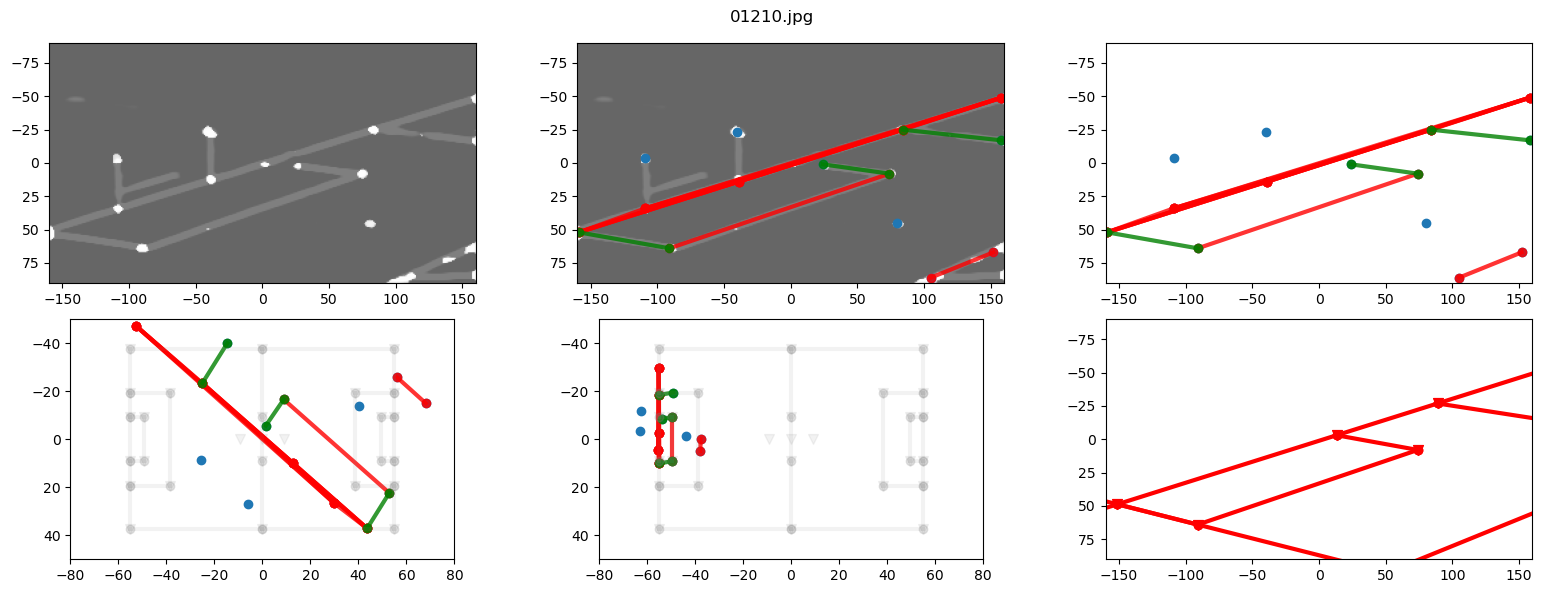

In [27]:
plot_full_pipeline(10)

  3%|▎         | 1/32 [00:01<00:57,  1.86s/it]

Pipeline did not reach to the end. Error: not enough values to unpack (expected 3, got 0)
[02725.png]. Pipeline failed.


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
  6%|▋         | 2/32 [00:35<10:12, 20.40s/it]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
  9%|▉         | 3/32 [00:43<07:05, 14.67s/it]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
 12%|█▎        | 4/32 [00:48<05:10, 11.09s/it]/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/sklearn/cluster/_affinity_propagation.py:50: UserWarning: All samples have mutually equal similarities. Returning arbitrary cluster center(s).
  warnings.warn(
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interact

Pipeline did not reach to the end. Error: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by AffinityPropagation.
[02731.png]. Pipeline failed.


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
 34%|███▍      | 11/32 [01:32<02:09,  6.18s/it]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
 38%|███▊      | 12/32 [01:42<02:27,  7.36s/it]/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/sklearn/cluster/_affinity_propagation.py:50: UserWarning: All samples have mutually equal similarities. Returning arbitrary cluster center(s).
  warnings.warn(
 41%|████      | 13/32 [01:44<01:48,  5.70s/it]

...

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/sklearn/cluster/_affinity_propagation.py:50: UserWarning: All samples have mutually equal similarities. Returning arbitrary cluster center(s).
  warnings.warn(
 91%|█████████ | 29/32 [03:31<00:09,  3.18s/it]

Pipeline did not reach to the end. Error: not enough values to unpack (expected 3, got 0)
[02527.png]. Pipeline failed.


 94%|█████████▍| 30/32 [03:32<00:05,  2.70s/it]

Pipeline did not reach to the end. Error: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by AffinityPropagation.
[02533.png]. Pipeline failed.


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
 97%|█████████▋| 31/32 [03:35<00:02,  2.72s/it]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_14196/888815408.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 32/32 [03:40<00:00,  6.88s/it]


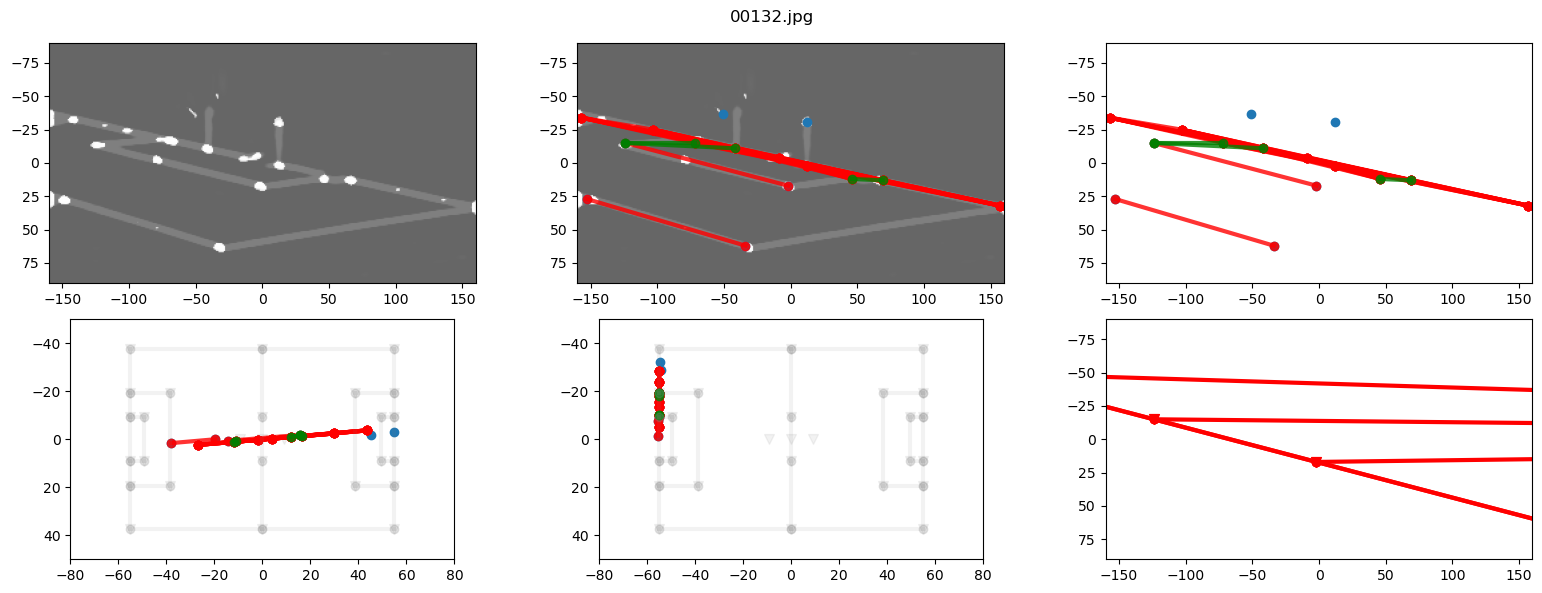

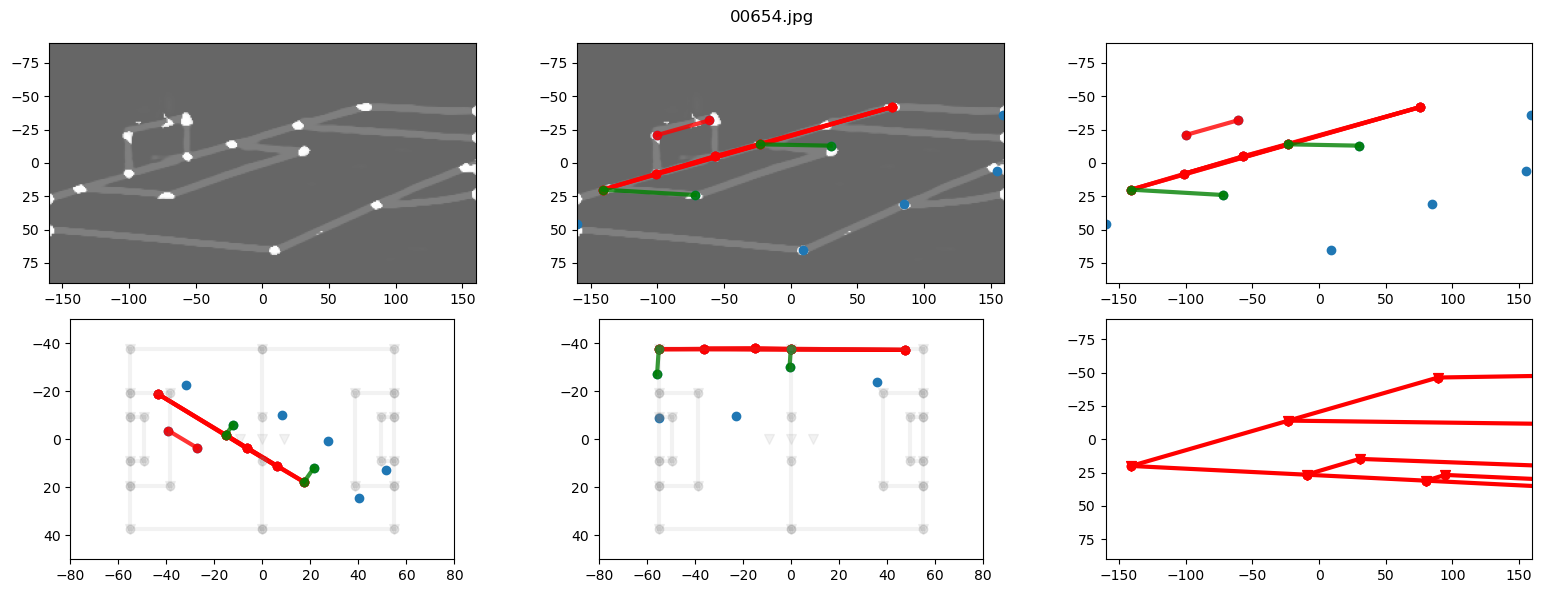

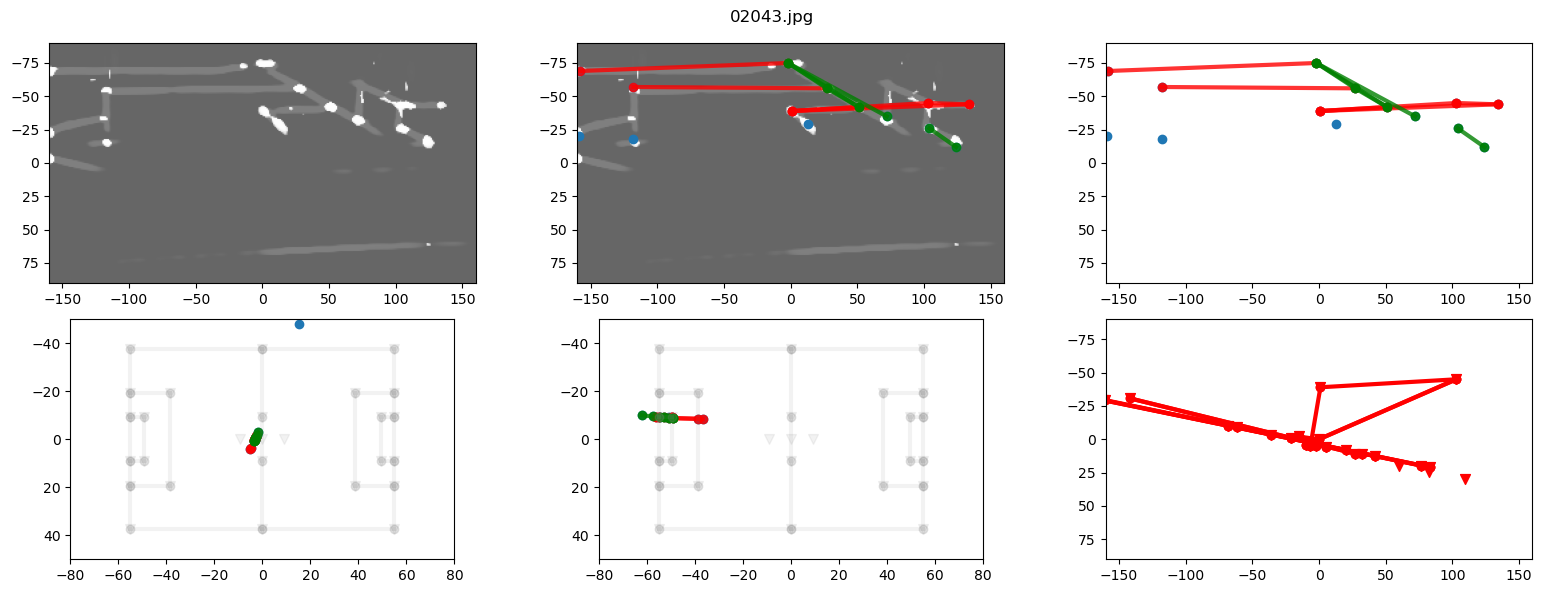

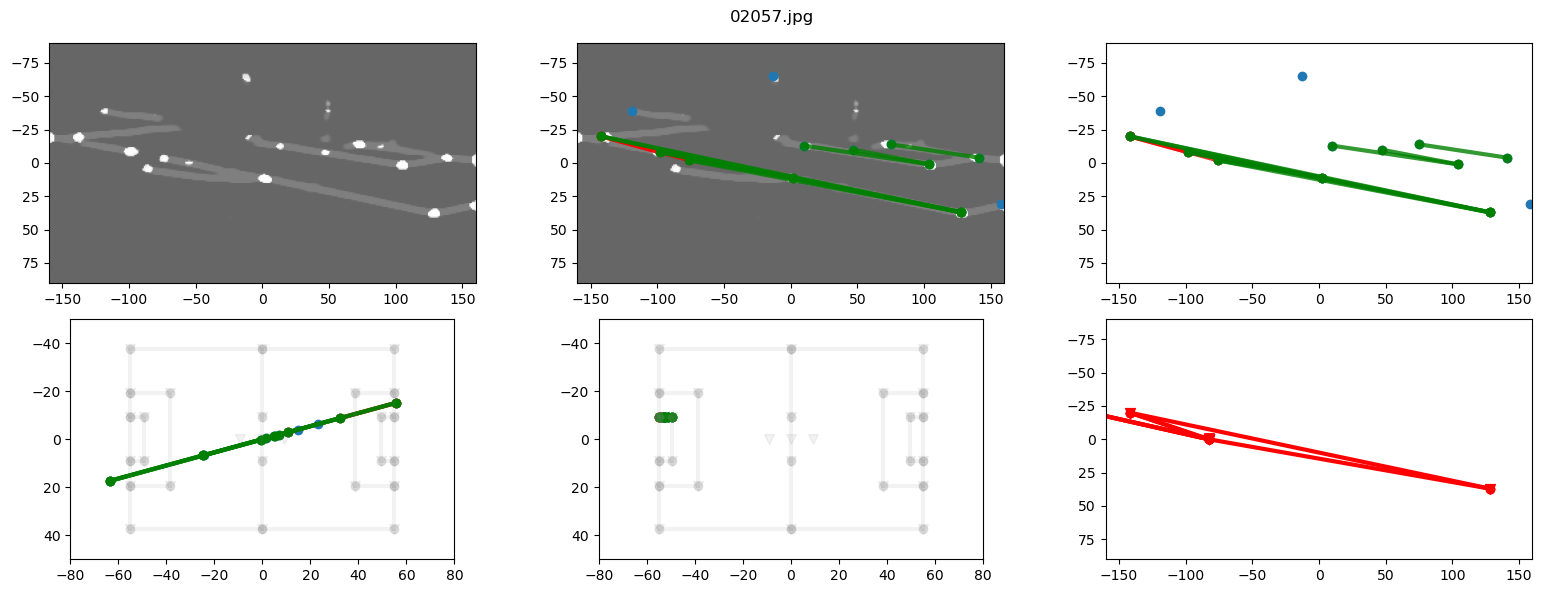

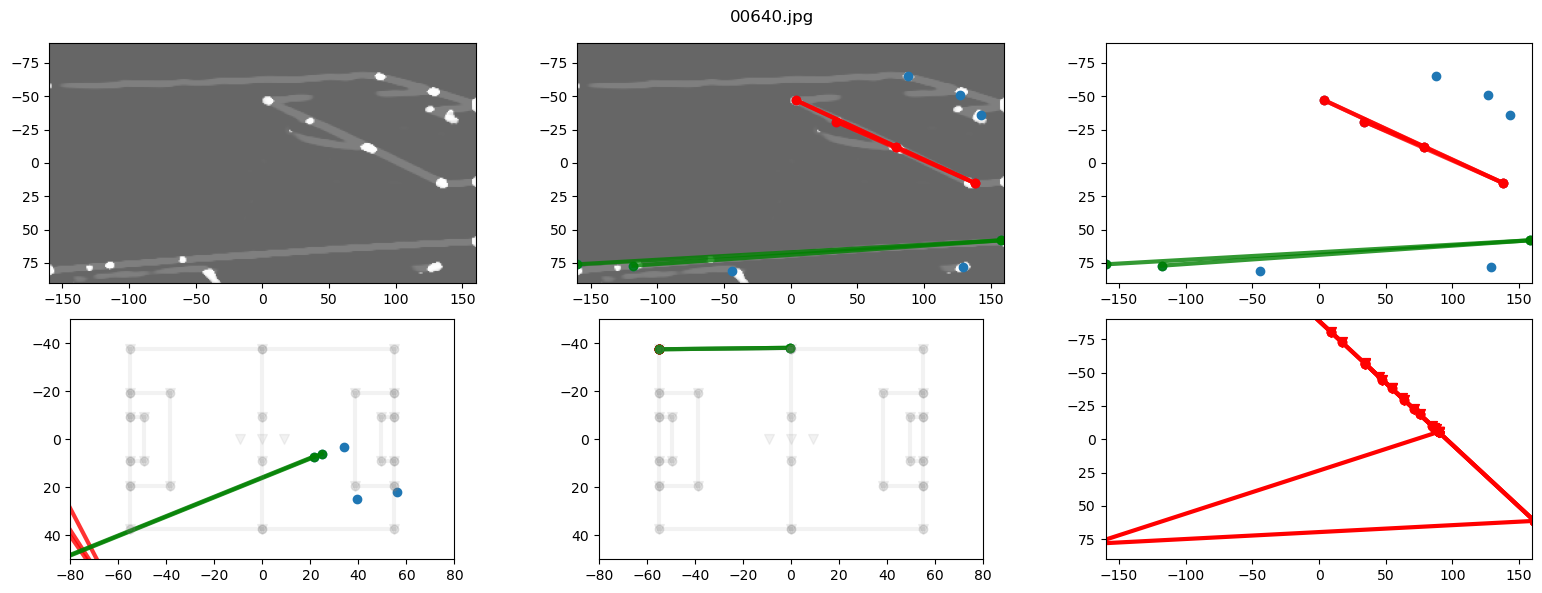

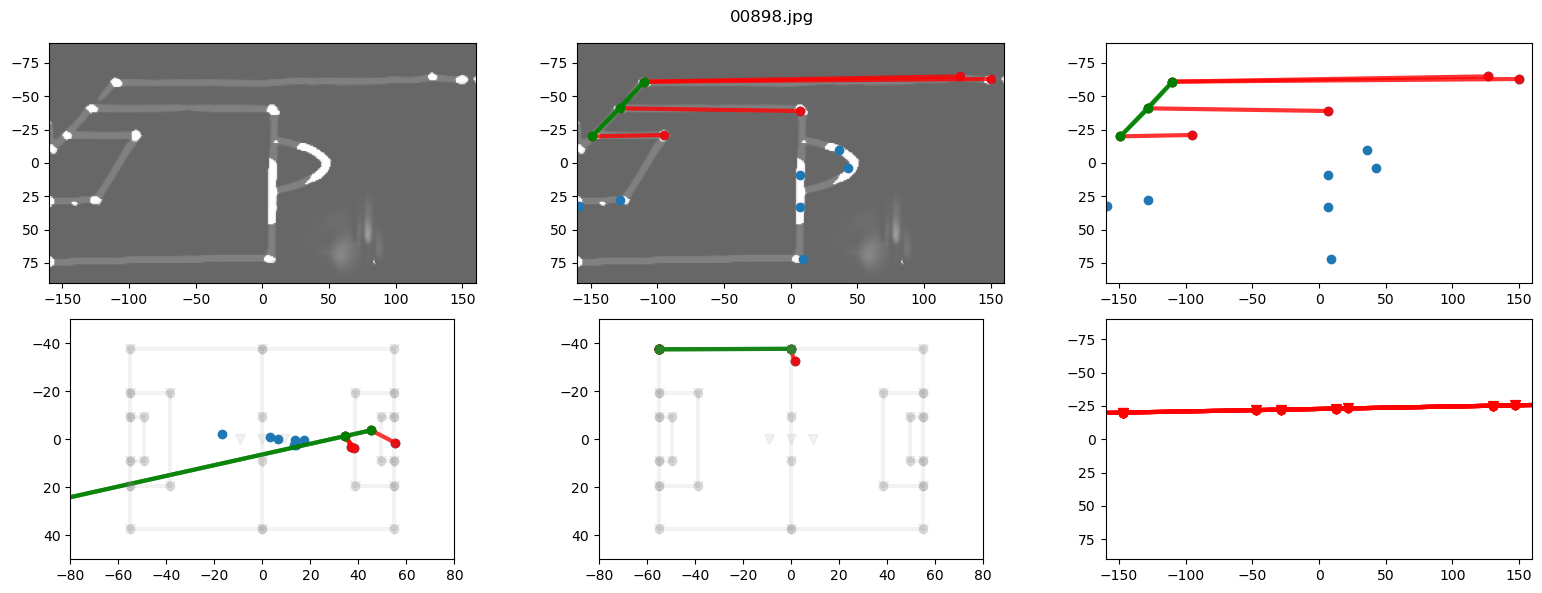

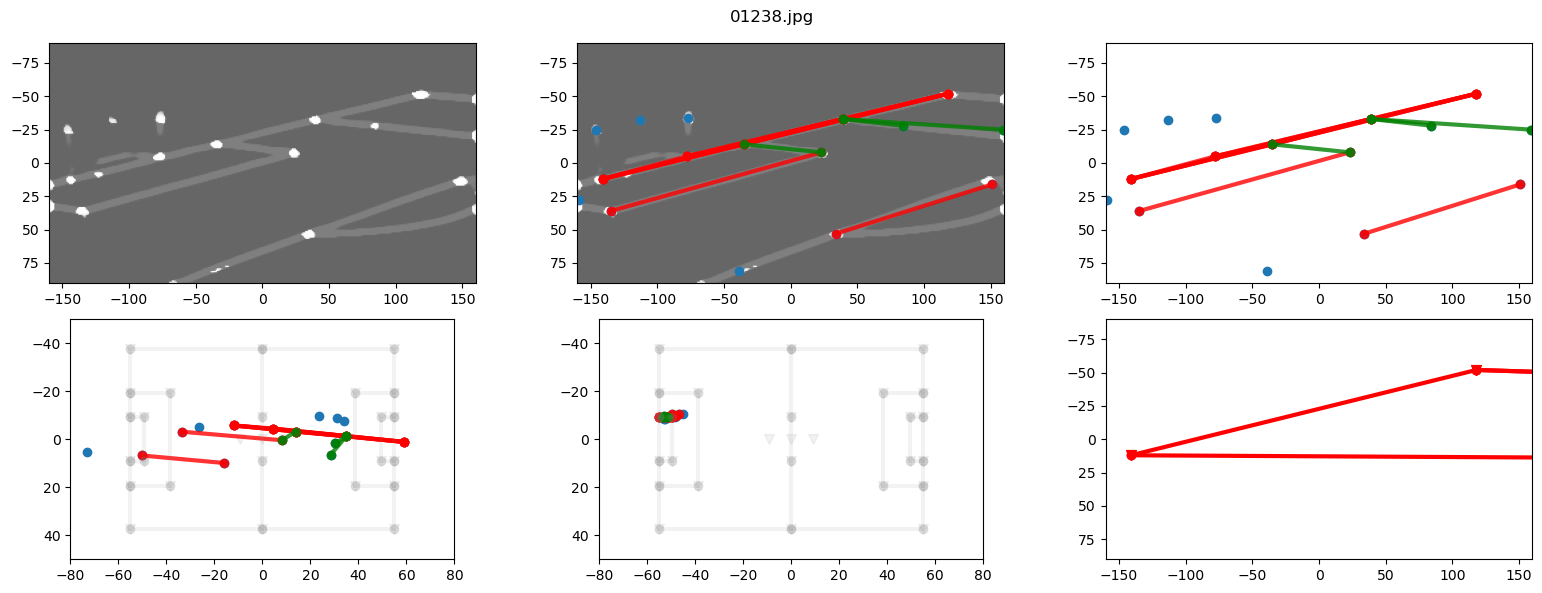

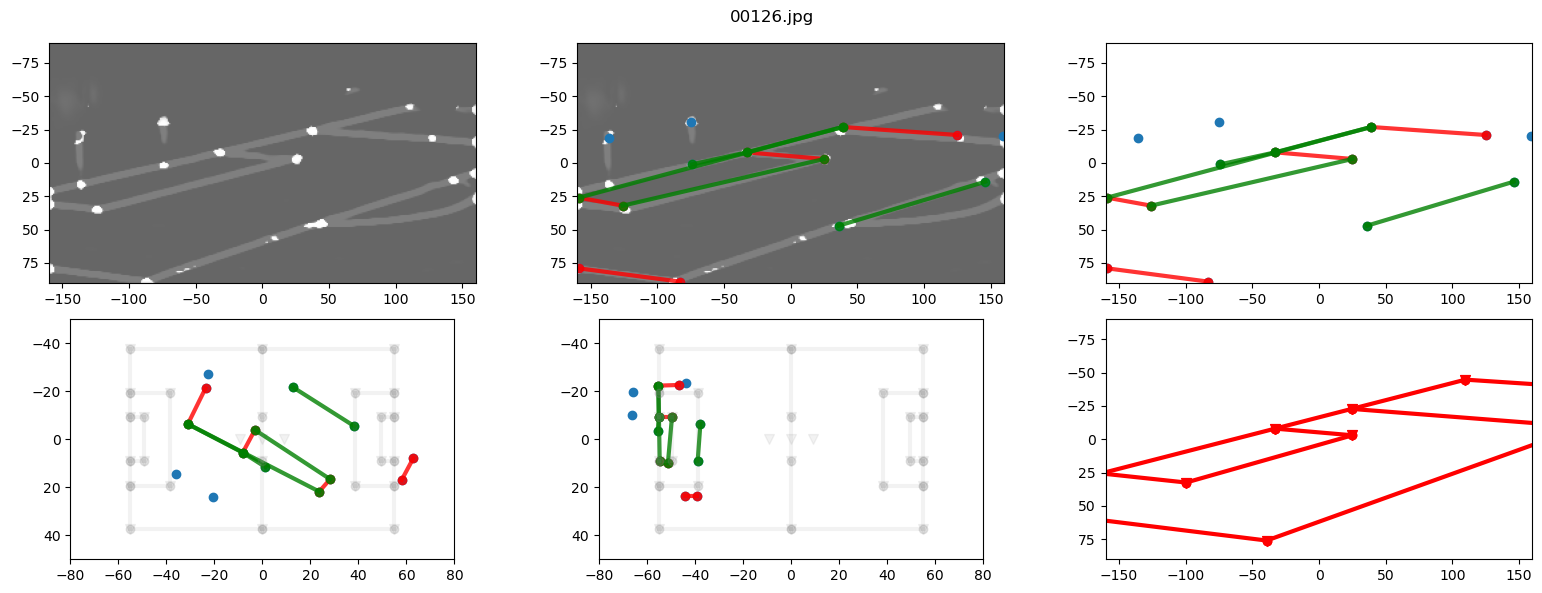

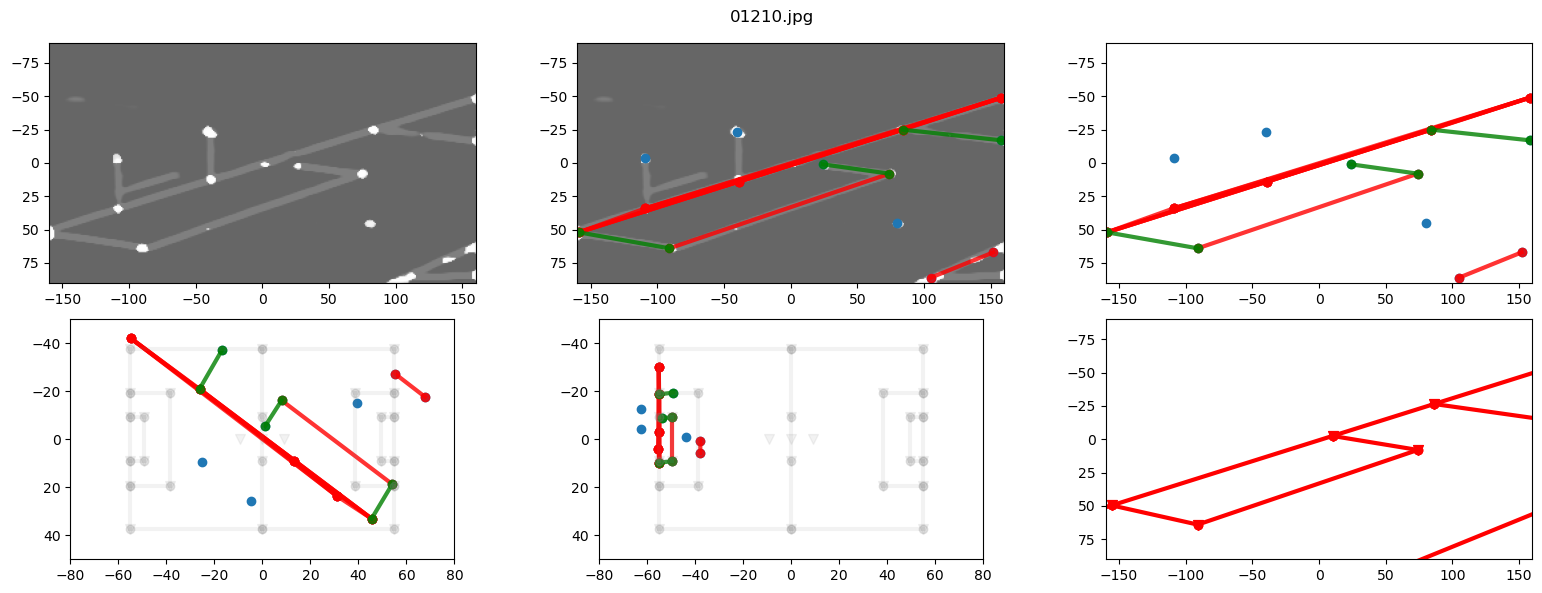

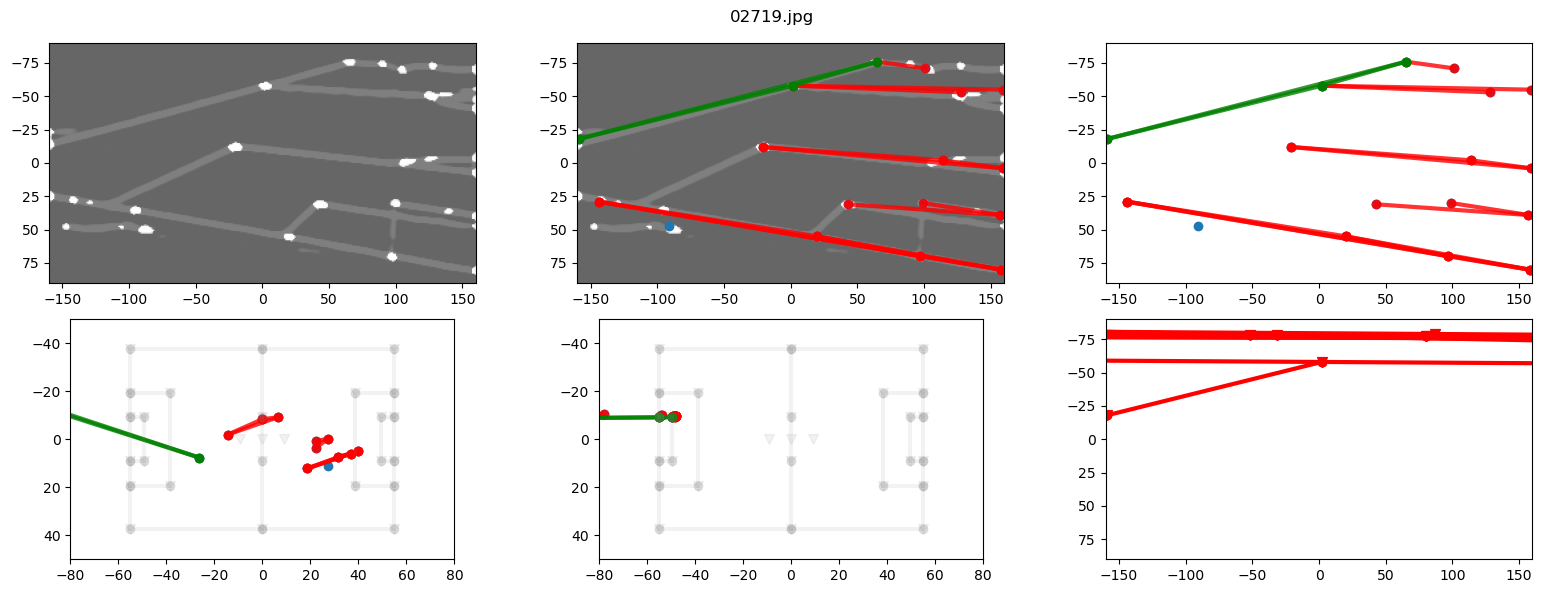

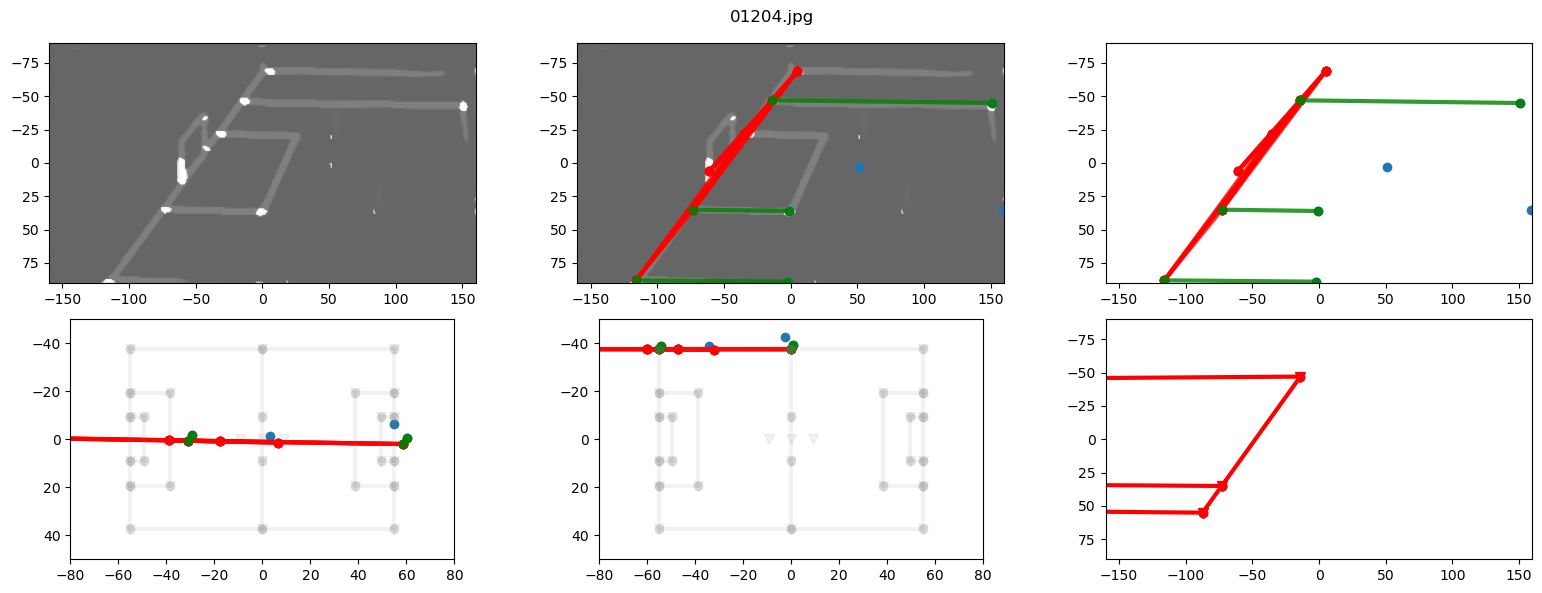

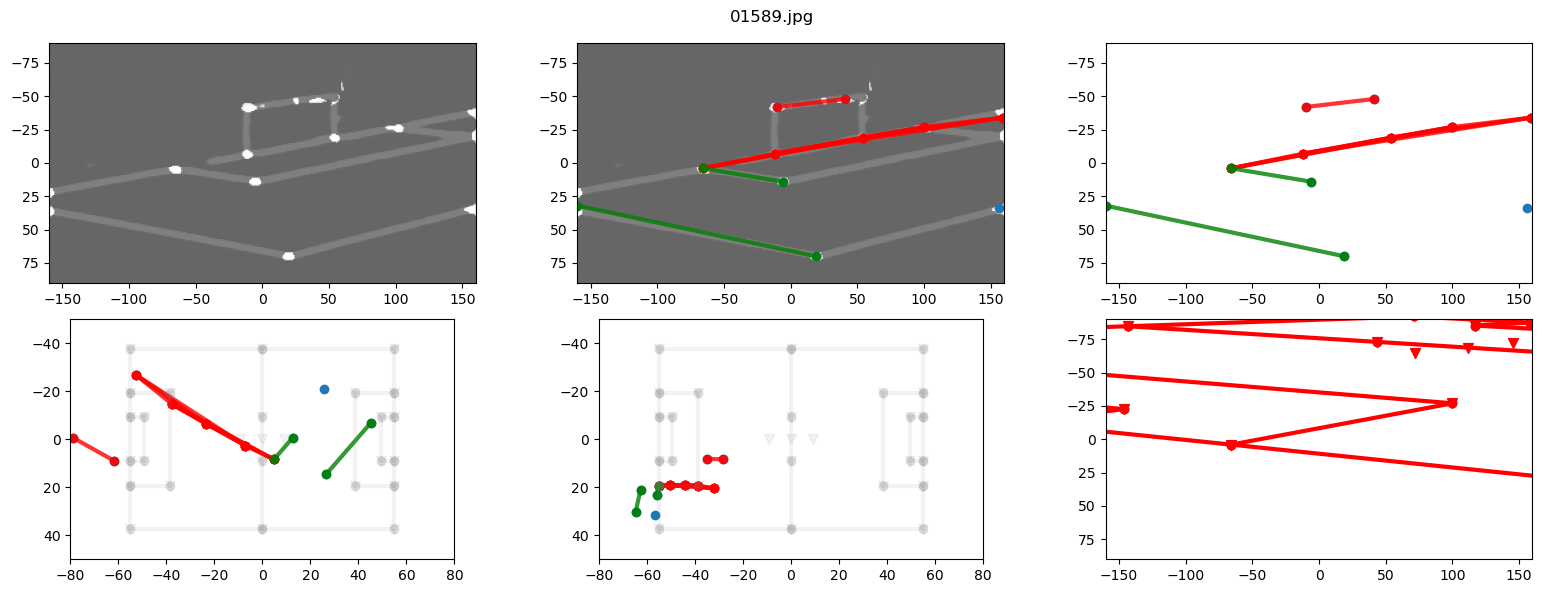

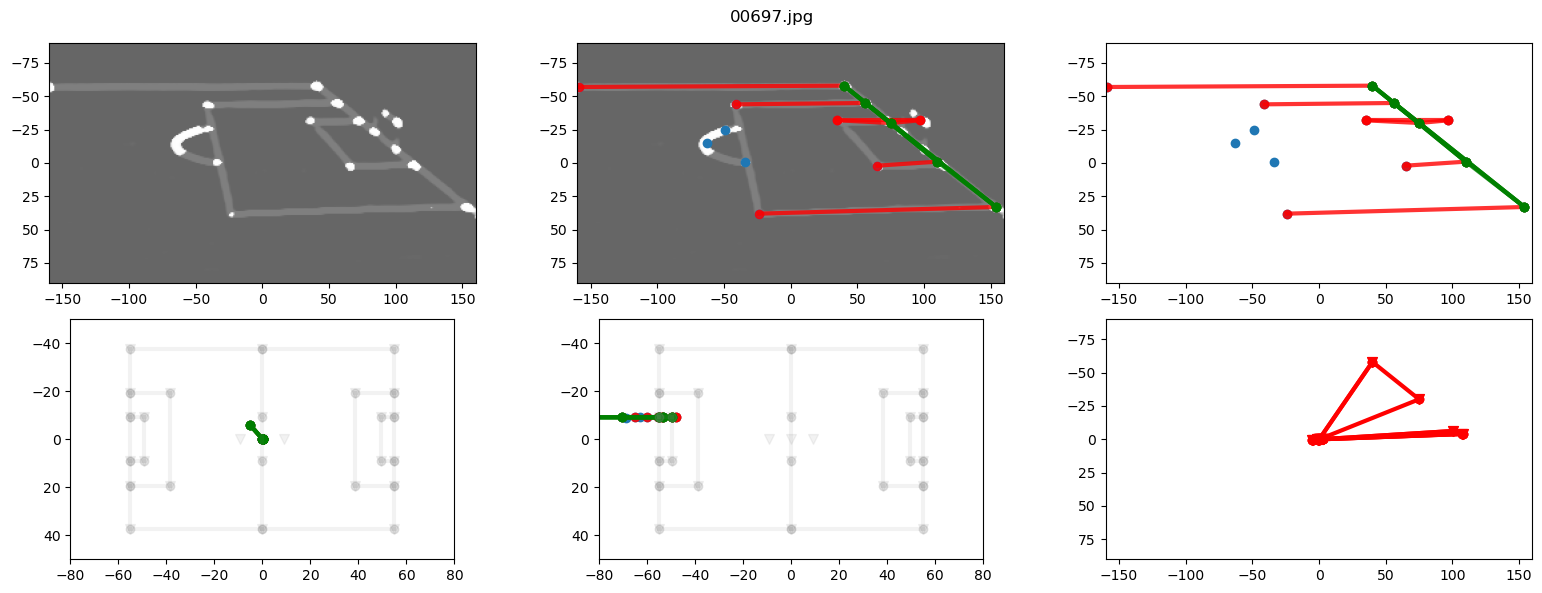

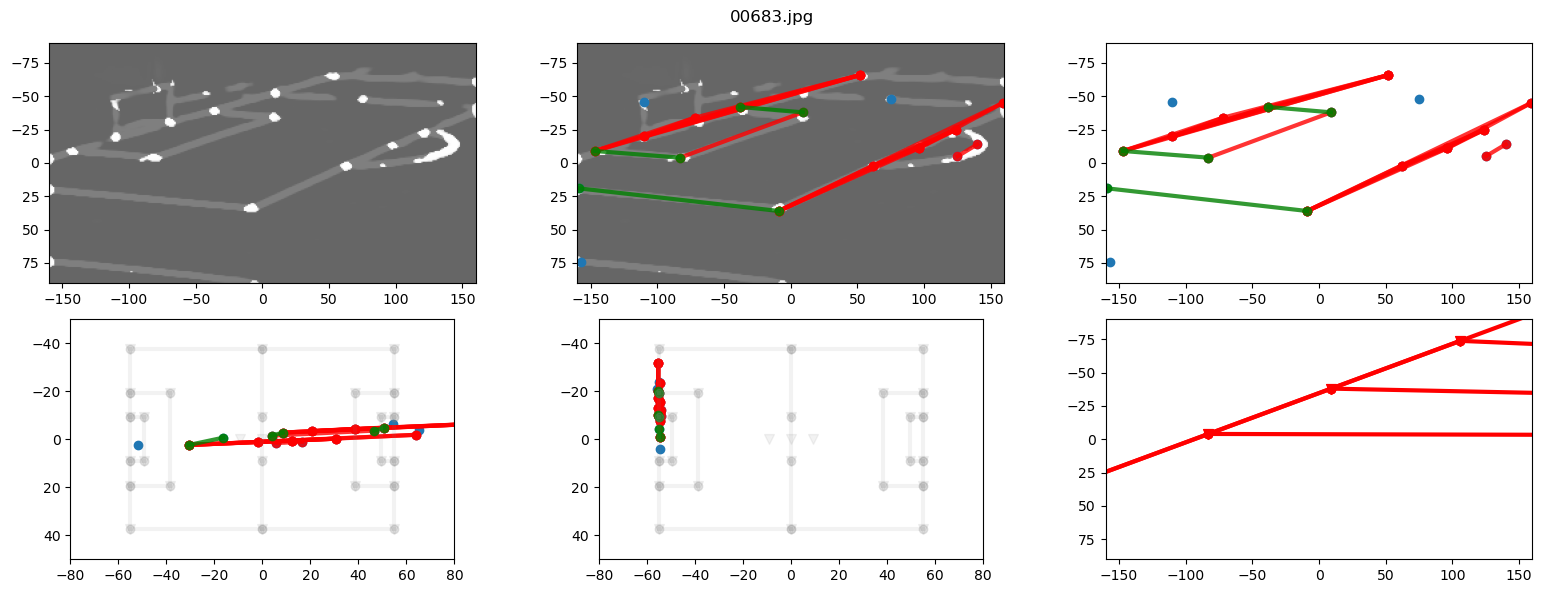

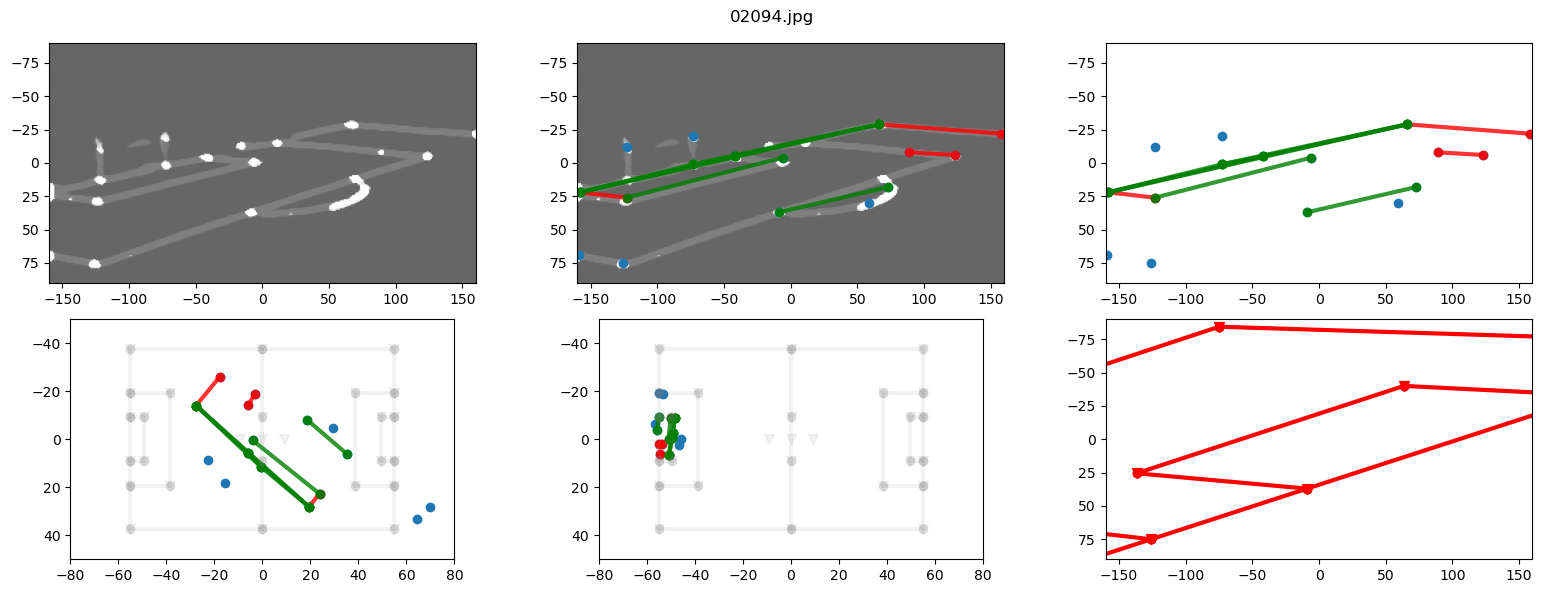

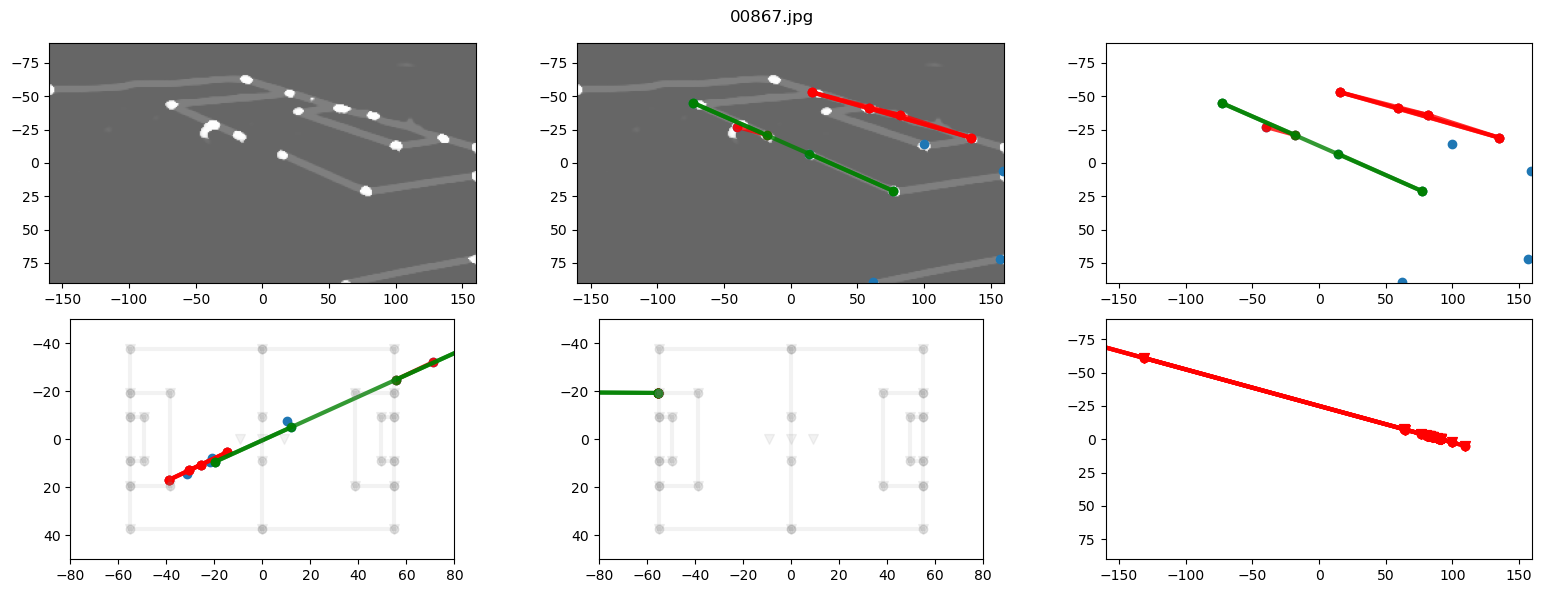

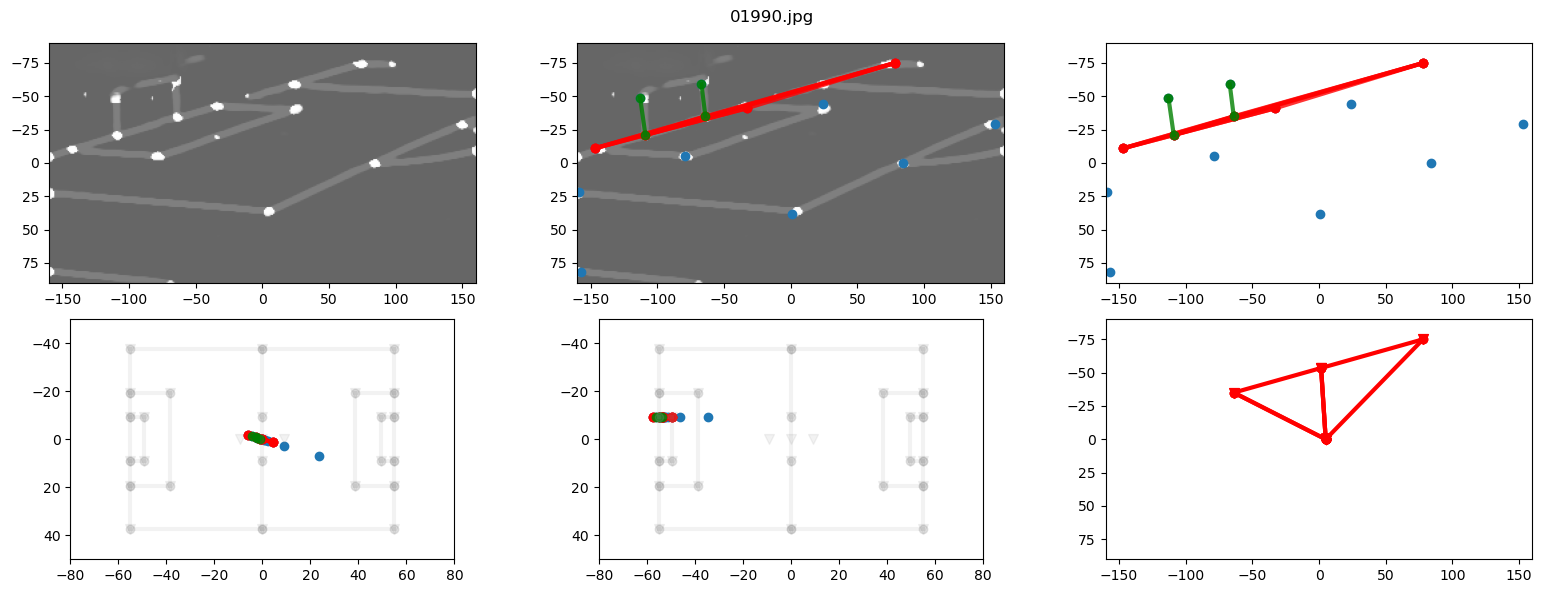

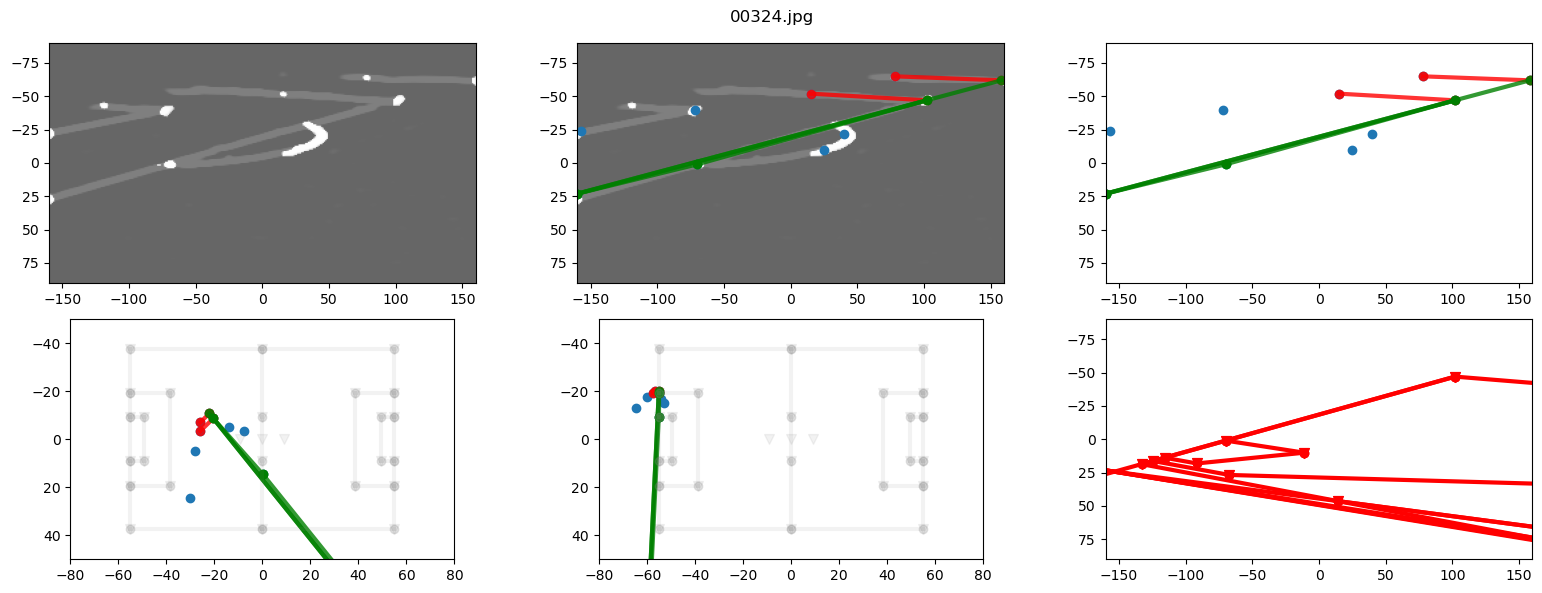

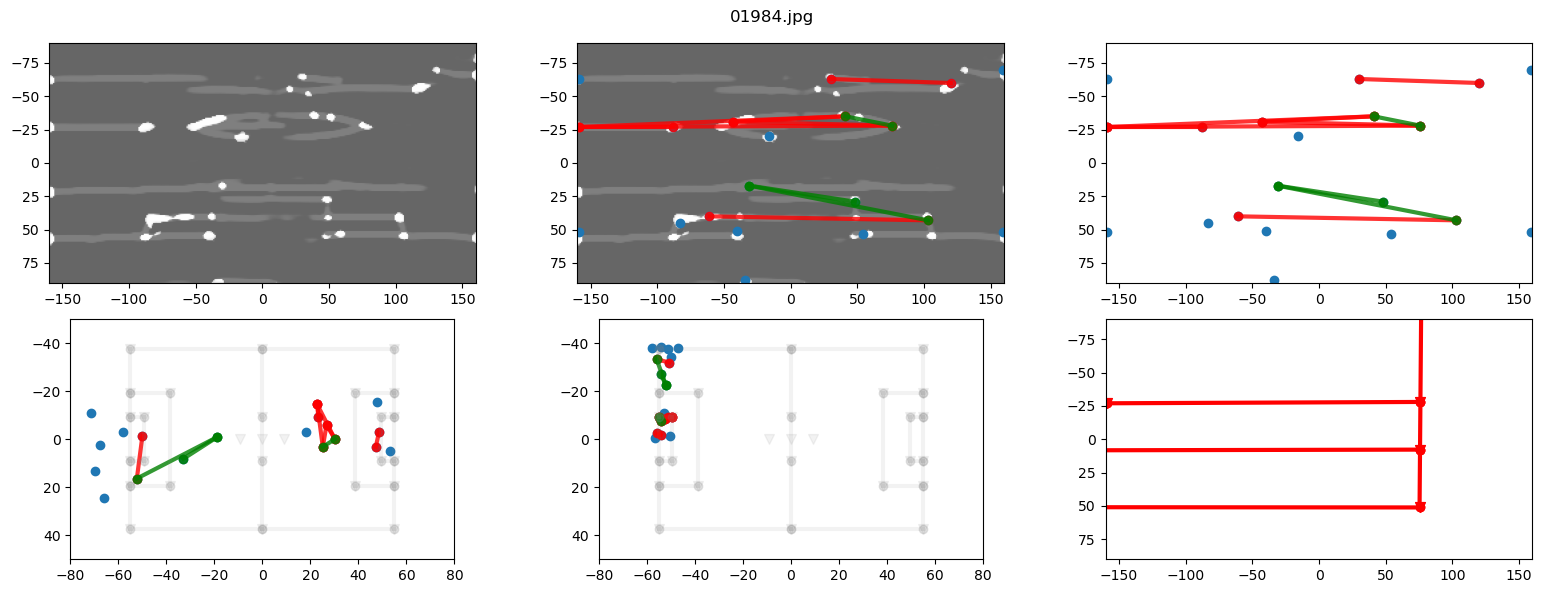

In [30]:
for idx in tqdm(range(0, 32)):
    plot_full_pipeline(idx)